## 7.19 폴라리톤 화학 (Polariton Chemistry)

In [1]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit_algorithms.time_evolvers import TimeEvolutionProblem, TrotterQRTE
from qiskit.primitives import StatevectorEstimator  # 호환성 수정: V1 Estimator → V2 StatevectorEstimator
from qiskit_aer import AerSimulator
from qiskit_algorithms.time_evolvers import TimeEvolutionResult
import matplotlib.pyplot as plt
from qiskit.visualization import plot_state_city
import numpy as np

import warnings
warnings.filterwarnings('ignore')

In [2]:
# 상수 정의
omega_m = 1.0  # 분자 들뜸 에너지 (임의 단위)
omega_c = 1.0  # 광공동 모드 에너지 (임의 단위)
g = 0.1        # 분자-공동 결합 세기
time = 1.0     # 진화 시간

In [3]:
# 2큐비트 계의 파울리 연산자 정의
# 파울리 연산자는 분자(큐비트 0)와 공동(큐비트 1)에 작용한다
Z_molecule = SparsePauliOp(["IZ"], [omega_m / 2])  # 분자 들뜸
Z_cavity = SparsePauliOp(["ZI"], [omega_c / 2])    # 공동 모드
X_molecule_cavity = SparsePauliOp(["XX"], [g])    # 결합 항 (X ⊗ X)
Y_molecule_cavity = SparsePauliOp(["YY"], [g])    # 결합 항 (Y ⊗ Y)

In [4]:
# 전체 해밀토니안 구성
H_molecule = Z_molecule
H_cavity = Z_cavity
H_interaction = X_molecule_cavity + Y_molecule_cavity
H_total = H_molecule + H_cavity + H_interaction

In [5]:
# 초기 상태 준비: 분자와 공동의 바닥상태
qc = QuantumCircuit(2)  # 분자와 공동용 두 큐비트
qc.x(0)  # 분자를 |1⟩, 공동을 |0⟩ 으로 시작

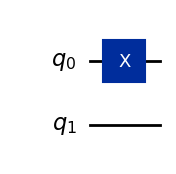

In [6]:
# 회로 시각화
qc.draw('mpl')

In [7]:
# Trotter화 시간 진화 방법 설정
trotter = TrotterQRTE()  # Trotter화 실시간 진화

In [8]:
# 시간 진화 문제 정의
evolution_problem = TimeEvolutionProblem(
    hamiltonian=H_total,
    initial_state=qc,
    time=time
)

In [9]:
# 시간 진화 시뮬레이션
simulator = AerSimulator()
trotter_result: TimeEvolutionResult = trotter.evolve(evolution_problem)

In [10]:
# 시뮬레이션 결과에서 상태벡터 회수
# 호환성 수정: evolved_state는 QuantumCircuit이므로 Statevector로 변환해 상태벡터를 얻는다
from qiskit.quantum_info import Statevector
statevector = Statevector(trotter_result.evolved_state).data

In [11]:
# 해밀토니안의 기대값 계산
# 호환성 수정: V2 Estimator API
estimator = StatevectorEstimator()
energy = float(np.asarray(estimator.run([(trotter_result.evolved_state, H_total)]).result()[0].data.evs))

In [12]:
# 결과 출력
print("진화한 상태벡터:")
print(statevector)
print("\n해밀토니안의 기대값:")
print(energy)

진화한 상태벡터:
[0.        +0.j         0.98006658+0.j         0.        -0.19866933j
 0.        +0.j        ]

해밀토니안의 기대값:
0.0
